In [2]:
import sys, os
# os.environ['PATH']='/projects/bdne/spandey3/tex/texlive/bin/x86_64-linux:'+ os.environ['PATH']
# os.environ['PYTHONPATH']='/projects/bdne/spandey3/tex/texlive/bin/x86_64-linux:'
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.9'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import jax_cosmo.background as bkgrd
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
# Change the current working directory to the desired path
# os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')

import matplotlib

import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = False
%load_ext autoreload
%autoreload 2
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../data/") 
abs_path_src = os.path.abspath(curr_path / "../src/") 
abs_path_results = os.path.abspath(curr_path / "../results/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
# pl.rc('font', family='DejaVu Sans')

%matplotlib inline
%load_ext autoreload
%autoreload 2



1 1
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from scipy.interpolate import interp1d
ks = np.geomspace(5e-2,50,15) # wavenumbers


from scipy.interpolate import interp1d
zedges = np.array([0.4, 0.6, 0.8,1.1])
nz_lrg_all = np.loadtxt(abs_path_data + '/pge/desi_lrg_nz.txt')
# nz_lrg_all.shape
zv, nzv = nz_lrg_all[:,0], nz_lrg_all[:,1]


zedges = np.array([0.4, 0.6, 0.8,1.1])
nz_lrg_all = np.loadtxt(abs_path_data + '/pge/desi_lrg_nz.txt')
# nz_lrg_all.shape
zv, nzv = nz_lrg_all[:,0], nz_lrg_all[:,1]


nbins_lens = len(zedges) - 1
zarray_lens = np.linspace(0.001, 1.6, 100)
nz_interp = interp1d(zv, nzv, fill_value=1e-10, bounds_error=False)
nz_zarray = nz_interp(zarray_lens)
nz_lens = {}
for jb in range(nbins_lens):
    nz_jb = np.zeros_like(nz_zarray)
    indsel = np.where((zarray_lens > zedges[jb]) & (zarray_lens < zedges[jb+1]))[0]
    nz_jb[indsel] = nz_zarray[indsel]
    norm_val = np.trapz(nz_jb, zarray_lens)
    nz_jb = nz_jb/norm_val
    nz_lens[jb] = nz_jb

df_nz_comoving = np.loadtxt(abs_path_data + '/pge/desi_lrg_comoving_density.txt')
    
zarray_comoving = df_nz_comoving[:,0]
nz_comoving = df_nz_comoving[:,1]


cosmo_params_dict = {'flat': True, 'H0': 67.66, 'Om0': 0.3111, 'Ob0': 0.0490, 'sigma8': 0.8102, 'ns': 0.9665, 'w0':-1.0}
# cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.29, 'Ob0': 0.049, 'sigma8': 0.783, 'ns': 0.95, 'w0':-1.0}
sim_params_dict = {}
sim_params_dict['nfw_trunc'] = True
# sim_params_dict['gamma_rhogas'] = 2.0
# sim_params_dict['delta_rhogas'] = 7.0

sim_params_dict['gamma_rhogas'] = 1.2
sim_params_dict['delta_rhogas'] = 6.0


sim_params_dict['theta_co_0'] = 0.01
sim_params_dict['log10_Mstar0_theta_co'] = 15.0
sim_params_dict['nu_theta_co_M'] = 0.0
sim_params_dict['nu_theta_co_z'] = 0.0

sim_params_dict['theta_ej_0'] = 3.0
sim_params_dict['log10_Mstar0_theta_ej'] = 15.0
sim_params_dict['nu_theta_ej_M'] = -0.025
sim_params_dict['nu_theta_ej_z'] = 0.025

sim_params_dict['log10_Mc0'] = 14.38
sim_params_dict['log10_Mstar0'] = 14.0
sim_params_dict['mu_beta'] = 0.6
sim_params_dict['nu_z'] = 0.0
sim_params_dict['nu_M'] = 0.0

sim_params_dict['eta_star'] = 0.3
sim_params_dict['eta_cga'] = 0.6


sim_params_dict['neg_bhse_plus_1'] = 0.833
sim_params_dict['A_starcga'] = 0.09
sim_params_dict['log10_M1_starcga'] = 11.4
sim_params_dict['epsilon_rt'] = 4.0


sim_params_dict['a_zeta'] = 0.3
sim_params_dict['n_zeta'] = 2
sim_params_dict['alpha_nt'] = 0.18
sim_params_dict['beta_nt'] = 0.5
sim_params_dict['n_nt'] = 0.3
sim_params_dict['cosmo'] = cosmo_params_dict

sim_params_dict['log10M1_fshmr'] = 12.35
sim_params_dict['log10Mstar0_fshmr'] = 10.72
sim_params_dict['beta_fshmr'] = 0.44
sim_params_dict['delta_fshmr'] = 0.57
sim_params_dict['gamma_fshmr'] = 1.56
sim_params_dict['Bcut_Nsat'] = 1.69
sim_params_dict['Bsat_Nsat'] = 9.01
sim_params_dict['betacut_Nsat'] = 0.6
sim_params_dict['betasat_Nsat'] = 0.74
sim_params_dict['alphasat_Nsat'] = 1.0
sim_params_dict['siglogMstar_Ncen'] = 0.25


halo_params_dict = {}
halo_params_dict['rmin'], halo_params_dict['rmax'], halo_params_dict['nr'] = 5e-3, 12, 24
halo_params_dict['zmin'], halo_params_dict['zmax'], halo_params_dict['nz'] = 0.01, 1.6, 16
halo_params_dict['lg10_Mmin'], halo_params_dict['lg10_Mmax'], halo_params_dict['nM'] = 11.0, 16.0, 20
# halo_params_dict['cmin'], halo_params_dict['cmax'], halo_params_dict['nc'] = 2, 9, 16

lmin = 10.0
lmax = 11000.0
fac = 1
dl_log_array = 0.23025851 / fac
# dl_log_array = 0.1
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
halo_params_dict['nell'] = len(l_array_survey)
halo_params_dict['ellmin'] = l_array_survey[0]
halo_params_dict['ellmax'] = l_array_survey[-1]
# halo_params_dict['ellmin'], halo_params_dict['ellmax'], halo_params_dict['nell'] = 8, 2**14, 32
# try:
halo_params_dict['sig_logc_z_array'] = np.ones(halo_params_dict['nz']) * 0.05
halo_params_dict['mdef'] = '200c'
halo_params_dict['hmf_model'] = 'T10'
# halo_params_dict['conc_model'] = 'Diemer15'
halo_params_dict['conc_model'] = 'Duffy08'
halo_params_dict['do_corr_2h_mm'] = True

# halo_params_dict['do_corr_2h_mm'] = False
analysis_dict = {}

from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/forecast/lsst_simulate_Y1.fits'))
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = z_array
nz_info_dict['nbins'] = 5
nz_info_dict['nz0'] = np.maximum(df['nz_source'].data['BIN1'], 1e-4)
nz_info_dict['nz1'] = np.maximum(df['nz_source'].data['BIN2'], 1e-4)
nz_info_dict['nz2'] = np.maximum(df['nz_source'].data['BIN3'], 1e-4)
nz_info_dict['nz3'] = np.maximum(df['nz_source'].data['BIN4'], 1e-4)
nz_info_dict['nz4'] = np.maximum(df['nz_source'].data['BIN5'], 1e-4)
analysis_dict['nz_source_info_dict'] = nz_info_dict

nz_info_dict = {}
nz_info_dict['z_array_lens'] = zarray_lens
nz_info_dict['nbins_lens'] = 3
nz_info_dict['nz0'] = np.maximum(nz_lens[0], 1e-4)
nz_info_dict['nz1'] = np.maximum(nz_lens[1], 1e-4)
nz_info_dict['nz2'] = np.maximum(nz_lens[2], 1e-4)
analysis_dict['nz_lens_info_dict'] = nz_info_dict

analysis_dict['zmin_pk'] = 0.01
analysis_dict['zmax_pk'] = 1.5
analysis_dict['nz_pk'] = 128

analysis_dict['do_ky'] = True
analysis_dict['do_kk'] = True
analysis_dict['do_gy'] = True
analysis_dict['do_gk'] = True
analysis_dict['do_gg'] = True
analysis_dict['do_ge'] = True

analysis_dict['fsky_yy'] = 0.4
analysis_dict['fsky_ky'] = 18000/41253
analysis_dict['fsky_kk'] = 18000/41253
analysis_dict['fsky_yg'] = (14000/41253)
analysis_dict['fsky_kg'] = 0.1
analysis_dict['fsky_gg'] = (14000/41253)

analysis_dict['fac_ell_hres'] = fac

theta_data = df['xip'].data['ANG'][0:20]

analysis_dict['angles_data_array'] = jnp.array(theta_data)
analysis_dict['beam_fwhm_arcmin'] = 1.6
analysis_dict['want_like_diff'] = True
analysis_dict['calc_nfw_only'] = False
analysis_dict['conc_dep_model'] = False

analysis_dict['model_galaxies'] = True

analysis_dict['verbose_time'] = False

analysis_dict['get_cov'] = True
analysis_dict['stats_for_cov'] = ['ky', 'kk', 'gy', 'gg', 'gk']
analysis_dict['analysis_coords'] = 'fourier'
# l_array_survey = np.logspace(np.log10(lmin), np.log10(lmax), int((lmax-lmin)/dl_log_array)+1)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)


h = cosmo_params_dict['H0']/100
ks = np.geomspace(5e-2,50,15) # wavenumbers
ks_wh = ks / h
analysis_dict['k_array_survey'] = jnp.array(ks_wh)

analysis_dict['dl_array_survey'] = jnp.array(dl_array)
analysis_dict['yy_total_ell_fname'] = os.path.abspath(abs_path_data + '/pge/Noise_fid_yy_beamed_1p4arcmin.txt')


analysis_dict['sigma_epsilon_SN_bins'] = [0.367, 0.367, 0.367, 0.367, 0.367]/np.sqrt(2)
analysis_dict['neff_arcmin2_SN_bins'] = [4.64, 4.64, 4.64, 4.64, 4.64]

Ngals_bins = 3.33*np.array([506905, 771875, 859824])
analysis_dict['nbar_lens_bins'] = Ngals_bins/(analysis_dict['fsky_gg']*41253*(60**2))

analysis_dict['num_points_trapz_int'] = 64
analysis_dict['num_points_trapz_int'] = 32

other_params_dict = {}
other_params_dict['A_IA'] = 0.0
other_params_dict['eta_IA'] = 0.0
other_params_dict['z0_IA'] = 0.62
other_params_dict['C1_rhocrit'] = 0.0134
other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])






In [8]:
from base_class import base_class
from get_radial_profiles import Profiles
from get_Pkzs import get_Pkz
from get_Cls import get_Cl
from get_Xis import get_xi

base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)
xis_test = get_xi(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cl_obj=Cls_test)



In [17]:
Cls_test.Cl_gal_gal_tot_mat.shape


(30, 3, 3)

In [20]:
from get_covs import get_cov
cov_test = get_cov(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cl_obj=Cls_test)




starting covariance of ky and ky
ky ky 1 0 1 0
ky ky 1 0 2 0
ky ky 1 0 3 0
ky ky 1 0 4 0
ky ky 1 0 5 0
ky ky 2 0 1 0
ky ky 2 0 2 0
ky ky 2 0 3 0
ky ky 2 0 4 0
ky ky 2 0 5 0
ky ky 3 0 1 0
ky ky 3 0 2 0
ky ky 3 0 3 0
ky ky 3 0 4 0
ky ky 3 0 5 0
ky ky 4 0 1 0
ky ky 4 0 2 0
ky ky 4 0 3 0
ky ky 4 0 4 0
ky ky 4 0 5 0
ky ky 5 0 1 0
ky ky 5 0 2 0
ky ky 5 0 3 0
ky ky 5 0 4 0
ky ky 5 0 5 0
starting covariance of ky and kk
ky kk 1 0 1 1
ky kk 1 0 1 2
ky kk 1 0 1 3
ky kk 1 0 1 4
ky kk 1 0 1 5
ky kk 1 0 2 1
ky kk 1 0 2 2
ky kk 1 0 2 3
ky kk 1 0 2 4
ky kk 1 0 2 5
ky kk 1 0 3 1
ky kk 1 0 3 2
ky kk 1 0 3 3
ky kk 1 0 3 4
ky kk 1 0 3 5
ky kk 1 0 4 1
ky kk 1 0 4 2
ky kk 1 0 4 3
ky kk 1 0 4 4
ky kk 1 0 4 5
ky kk 1 0 5 1
ky kk 1 0 5 2
ky kk 1 0 5 3
ky kk 1 0 5 4
ky kk 1 0 5 5
ky kk 2 0 1 1
ky kk 2 0 1 2
ky kk 2 0 1 3
ky kk 2 0 1 4
ky kk 2 0 1 5
ky kk 2 0 2 1
ky kk 2 0 2 2
ky kk 2 0 2 3
ky kk 2 0 2 4
ky kk 2 0 2 5
ky kk 2 0 3 1
ky kk 2 0 3 2
ky kk 2 0 3 3
ky kk 2 0 3 4
ky kk 2 0 3 5
ky kk 2 0 4 1
ky kk 2 0 

In [21]:
probes_all = ['ky', 'kk', 'gy', 'gg', 'gk']

bin_comb_all_wprobe = []
count_all_probes = 0
for jp in range(len(probes_all)):
    probe = probes_all[jp]
    bin_comb_all = cov_test.Cl_result_dict[probe]['bin_combs']
    
    # bin_comb_sel = []
    for bin_comb in bin_comb_all:
        bin1 = bin_comb[0]
        bin2 = bin_comb[1]
        if probe in ['kk','gg']: 
            if bin2 >= bin1:
                bin_comb_all_wprobe.append([probe,[bin1, bin2]])
                count_all_probes += 1
        else:
            bin_comb_all_wprobe.append([probe,[bin1, bin2]])
            count_all_probes += 1

print(count_all_probes)






44


In [23]:
nell = len(l_array_survey)
nell_all = nell * count_all_probes 

nbl = analysis_dict['nz_lens_info_dict']['nbins_lens']
nk = len(analysis_dict['k_array_survey'])
cov_mat_all = np.zeros((nell_all + nbl*nk, nell_all + nbl*nk))
for jp1 in range(len(bin_comb_all_wprobe)):
    for jp2 in range(len(bin_comb_all_wprobe)):
        binwprobe1 = bin_comb_all_wprobe[jp1]
        binwprobe2 = bin_comb_all_wprobe[jp2]        
        probe1 = binwprobe1[0]
        probe2 = binwprobe2[0]
        bin_comb1 = binwprobe1[1]
        bin_comb2 = binwprobe2[1]
        b1, b2 = bin_comb1[0], bin_comb1[1]
        b3, b4 = bin_comb2[0], bin_comb2[1]
        try:
            cov_mat_all[jp1*nell:(jp1+1)*nell, jp2*nell:(jp2+1)*nell] = cov_test.covtot_dict[f'{probe1}_{probe2}'][f'bin_{b1}_{b2}_{b3}_{b4}']
        except:
            cov_mat_all[jp1*nell:(jp1+1)*nell, jp2*nell:(jp2+1)*nell] = cov_test.covtot_dict[f'{probe2}_{probe1}'][f'bin_{b3}_{b4}_{b1}_{b2}']

# cov_mat_all[nell_all:(nell_all+nk), nell_all:(nell_all+nk)] = np.clip(Pge_err_z0, 1e-10, 1e10)**2 * np.eye(nk)
# cov_mat_all[nell_all+nk:(nell_all+2*nk), nell_all+nk:(nell_all+2*nk)] = np.clip(Pge_err_z1, 1e-10, 1e10)**2 * np.eye(nk)
# cov_mat_all[nell_all+2*nk:(nell_all+3*nk), nell_all+2*nk:(nell_all+3*nk)] = np.clip(Pge_err_z2, 1e-10, 1e10)**2 * np.eye(nk)
            


In [24]:
probe_boundaries = np.array([5,15,3,6, 15])
probe_boundaries_cs = np.cumsum(probe_boundaries)
probe_boundaries_center = probe_boundaries_cs - (probe_boundaries/2)
# print(probe_boundaries_cs)
probe_boundaries_edge_right = probe_boundaries_cs
probe_boundaries_edge_left = probe_boundaries_cs - probe_boundaries
ell_edge_left = nell*probe_boundaries_edge_left
ell_edge_right = nell*probe_boundaries_edge_right
probes_all.append('ge')
ell_edge_left = np.append(ell_edge_left, ell_edge_right[-1])
ell_edge_right = np.append(ell_edge_right, ell_edge_right[-1] + 3*nk)





([<matplotlib.axis.YTick at 0x1552e30baef0>,
 [Text(0, 75.0, '$\\langle \\kappa y \\rangle$'),
  Text(0, 375.0, '$\\langle \\kappa \\kappa  \\rangle$'),
  Text(0, 645.0, '$\\langle g y \\rangle$'),
  Text(0, 780.0, '$\\langle gg \\rangle$'),
  Text(0, 1095.0, '$\\langle g \\kappa \\rangle$'),
  Text(0, 1342.5, '$\\langle g e \\rangle$')])

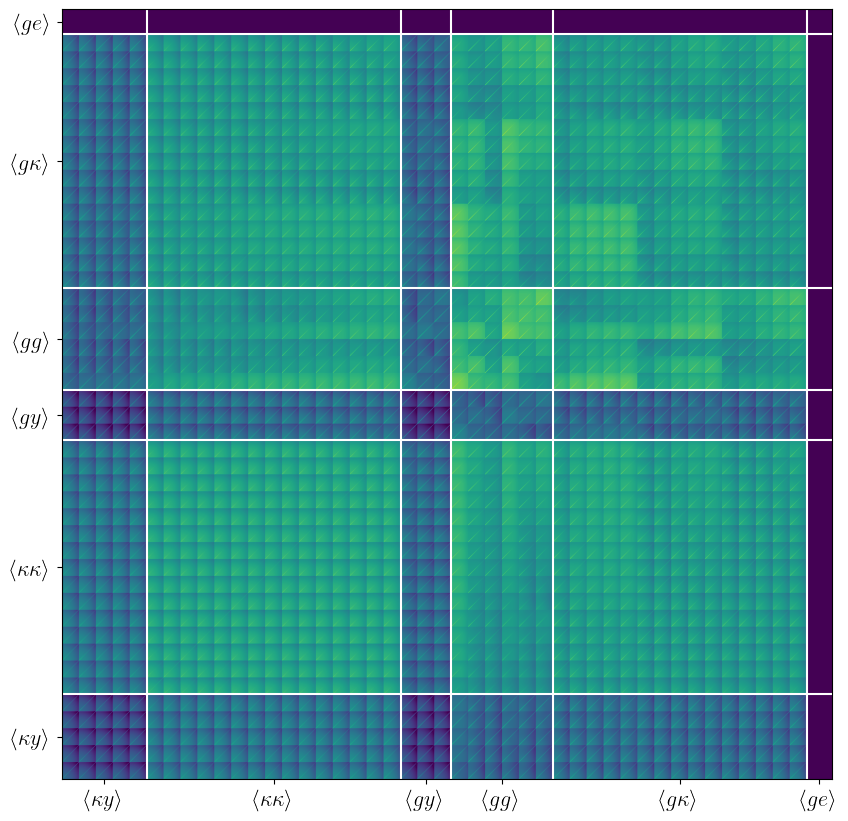

In [25]:
pl.figure(figsize=(10,10))
pl.imshow(np.log(np.abs(cov_mat_all + 1e-70)), origin='lower', vmin=-100, vmax=-20)
pl.axhline(probe_boundaries_cs[0]*nell, color='white')
pl.axhline(probe_boundaries_cs[1]*nell, color='white')
pl.axhline(probe_boundaries_cs[2]*nell, color='white')
pl.axhline(probe_boundaries_cs[3]*nell, color='white')
pl.axhline(probe_boundaries_cs[4]*nell, color='white')

pl.axvline(probe_boundaries_cs[0]*nell, color='white')
pl.axvline(probe_boundaries_cs[1]*nell, color='white')
pl.axvline(probe_boundaries_cs[2]*nell, color='white')
pl.axvline(probe_boundaries_cs[3]*nell, color='white')
pl.axvline(probe_boundaries_cs[4]*nell, color='white')

# write custom text as x-axis labels at a given tick values:
# pl.xticks(probe_boundaries_center*nell, ['ky', 'kk', 'gy', 'gg', 'gk'], fontsize=16)
ticks_loc = np.append(probe_boundaries_center*nell, [probe_boundaries_cs[-1]*nell + 1.5*nk])
pl.xticks(ticks_loc, [r'$\langle \kappa y \rangle$', r'$\langle \kappa \kappa  \rangle$', r'$\langle g y \rangle$', r'$\langle gg \rangle$', r'$\langle g \kappa \rangle$', r'$\langle g e \rangle$'], fontsize=16)
pl.yticks(ticks_loc, [r'$\langle \kappa y \rangle$', r'$\langle \kappa \kappa  \rangle$', r'$\langle g y \rangle$', r'$\langle gg \rangle$', r'$\langle g \kappa \rangle$', r'$\langle g e \rangle$'], fontsize=16)
# pl.imshow(cov_mat_all[1050:,1050:], origin='lower')
# pl.savefig('cov_mat_all_new_try2.pdf', bbox_inches='tight', dpi=300)


In [11]:
from get_B12_profile import Battaglia_12_16
import helpers.constants as constants
B12_test = Battaglia_12_16({'cosmo':cosmo_params_dict, 'init_power':False}, halo_params_dict)





In [12]:
from astropy.io import fits
df = fits.open('/mnt/home/spandey/ceph/websky/halo_input_wM200c_zmax2p5_minM200m_noh_5e13.fits')
# df[1].header
ra_all = df[1].data['ra']
dec_all = df[1].data['dec']
z_all = df[1].data['z']
M200c_all = df[1].data['M200c_wh']
M200m_all = df[1].data['M200m_wh']
vlos_all = df[1].data['vrad']
# c200c_all = df[1].data['c200c']
indsel = np.where((M200m_all > 6e13) & (z_all<1.0))[0]
print(len(indsel), len(M200c_all))
ra_all = ra_all[indsel]
dec_all = dec_all[indsel]
z_all = z_all[indsel]
M200c_all = M200c_all[indsel]
vlos_all = vlos_all[indsel]




1082043 4349354


In [13]:
import pickle as pk
import jax
import scipy.interpolate as interp
import healpy as hp
import numpy as np
from multiprocessing import Pool, cpu_count
from astropy.io import fits
# import constants
import jax_cosmo.background as bkgrd
from get_sim_maps import get_sim_map
import h5py as h5


jax.clear_caches()
nside = 1024
sdir = '/mnt/home/spandey/ceph/GODMAX/notebooks/mock_gen/maps_websky/'
save_kszmap_fname = sdir + f'tSZ_sim_B12_testv3_nside_{nside}.pkl'
# if not os.path.exists(save_kszmap_fname):
halo_ra, halo_dec = ra_all, dec_all
halo_z = z_all
halo_m = M200c_all
# indsel = np.where((np.log10(halo_m) > 12.75))[0]
# halo_m = halo_m[indsel]
# halo_ra = halo_ra[indsel]
# halo_dec = halo_dec[indsel]
# halo_z = halo_z[indsel]
# indsel = np.where((halo_z < 0.95))[0]
# halo_m = halo_m[indsel]
# halo_ra = halo_ra[indsel]
# halo_dec = halo_dec[indsel]
# halo_z = halo_z[indsel]
print('number of halos: ', len(halo_m))
M_all = halo_m
ra_all = halo_ra
dec_all = halo_dec
z_all = halo_z
# vlos_all = np.zeros_like(z_all)
nsel = len(M_all)

# nh_max = 4e4
nh_max = 4e5
if nsel > nh_max:
    num_chunks = int(np.ceil(nsel / nh_max))
else:
    num_chunks = 1


tszmap_test = np.zeros(12*nside**2)
for i in range(num_chunks):
# for i in range(1):
    print(f'chunk {i+1}/{num_chunks}')
    if i == num_chunks - 1:
        M_all_chunk = M_all[int(i*nh_max):]
        ra_all_chunk = ra_all[int(i*nh_max):]
        dec_all_chunk = dec_all[int(i*nh_max):]
        z_all_chunk = z_all[int(i*nh_max):]
        vlos_all_chunk = vlos_all[int(i*nh_max):]
    else:
        M_all_chunk = M_all[int(i*nh_max):int((i+1)*nh_max)]
        ra_all_chunk = ra_all[int(i*nh_max):int((i+1)*nh_max)]
        dec_all_chunk = dec_all[int(i*nh_max):int((i+1)*nh_max)]
        z_all_chunk = z_all[int(i*nh_max):int((i+1)*nh_max)]
        vlos_all_chunk = vlos_all[int(i*nh_max):int((i+1)*nh_max)]

    mock_params_dict = {}
    mock_params_dict['halo_z'] = jnp.array(z_all_chunk)
    mock_params_dict['halo_ra'] = jnp.array(ra_all_chunk)
    mock_params_dict['halo_dec'] = jnp.array(dec_all_chunk)
    mock_params_dict['halo_M'] = jnp.array(M_all_chunk)
    mock_params_dict['halo_vlos'] = jnp.array(vlos_all_chunk)
    mock_params_dict['nside'] = nside
    mock_params_dict['get_ymap'] = True

    halo_cat_scale_fac = 1./(1. + z_all_chunk)

    halo_cat_rho_c_z = constants.RHO_CRIT_0_KPC3 * bkgrd.Esqr(B12_test.cosmo_jax,halo_cat_scale_fac) * 1e9
    mdef_delta=200
    halo_cat_rho_treshold = mdef_delta * halo_cat_rho_c_z


    halo_cat_R200c = (M_all_chunk * 3.0 / 4.0 / jnp.pi / halo_cat_rho_treshold)**(1.0 / 3.0)
    halo_cat_DA = bkgrd.angular_diameter_distance(B12_test.cosmo_jax,halo_cat_scale_fac)
    max_paint_R200c_factor = 3.


    # ra_all_np = np.clip(np.array(ra_all_chunk), 0., 360.)
    # dec_all_np = np.clip(np.array(dec_all_chunk), -90., 90.)
    ra_all_np = np.array(ra_all_chunk)
    dec_all_np = np.array(dec_all_chunk)
    z_all_np = np.array(z_all_chunk)
    halo_cat_R200c_np = np.array(halo_cat_R200c)
    halo_cat_DV_np = np.array(halo_cat_DA)
    halo_vlos_np = np.array(vlos_all_chunk)
    def process_halo(jhalo):
        vec = hp.ang2vec(ra_all_np[jhalo], dec_all_np[jhalo], lonlat=True)

        nearby_angle = max_paint_R200c_factor * halo_cat_R200c_np[jhalo] / halo_cat_DV_np[jhalo]
        nearby_pix = hp.query_disc(mock_params_dict['nside'], vec, nearby_angle)

        nearby_ra, nearby_dec = hp.pix2ang(mock_params_dict['nside'], nearby_pix, lonlat=True)

        def hav(theta):
            return np.sin(theta / 2.) ** 2.

        ra1, dec1 = ra_all_np[jhalo] * np.pi / 180., dec_all_np[jhalo] * np.pi / 180.
        ra2, dec2 = nearby_ra * np.pi / 180., nearby_dec * np.pi / 180.
        theta = 2. * np.arcsin(np.sqrt(hav(dec1 - dec2) + np.cos(dec1) * np.cos(dec2) * hav(ra1 - ra2)))

        physical_distances_jhalo = halo_cat_DV_np[jhalo] * theta

        nearby_pix_array = np.array(nearby_pix)
        distances_pix_array = np.array(physical_distances_jhalo)
        logM_ind_array = np.ones(len(nearby_pix)) * np.log(M_all_chunk[jhalo])
        z_ind_array = np.ones(len(nearby_pix)) * z_all_chunk[jhalo]
        v_los_ind_array = np.ones(len(nearby_pix)) * halo_vlos_np[jhalo]
        return (nearby_pix_array, distances_pix_array, logM_ind_array, z_ind_array, v_los_ind_array, len(nearby_pix))

    def concatenate_results(results):
        # Pre-compute lengths for each part
        lengths = np.array([len(result[0]) for result in results])
        total_length = lengths.sum()

        # Pre-allocate arrays
        nearby_pix_all = np.empty(total_length, dtype=int)
        distances_pix_all = np.empty(total_length)
        logM_ind_all = np.empty(total_length)
        z_ind_all = np.empty(total_length)
        vlos_ind_all = np.empty(total_length)

        # Calculate start and end indices
        end_ind_all = np.cumsum(lengths)
        start_ind_all = np.roll(end_ind_all, 1)
        start_ind_all[0] = 0

        # Use array slicing for assignment
        for i, (start, end, result) in enumerate(zip(start_ind_all, end_ind_all, results)):
            nearby_pix_all[start:end] = result[0]
            distances_pix_all[start:end] = result[1]
            logM_ind_all[start:end] = result[2]
            z_ind_all[start:end] = result[3]
            vlos_ind_all[start:end] = result[4]

        return nearby_pix_all, distances_pix_all, start_ind_all, end_ind_all, logM_ind_all, z_ind_all, vlos_ind_all


    # if __name__ == "__main__":
    with Pool(cpu_count()) as pool:
        results = pool.map(process_halo, range(len(z_all_chunk)))

    nearby_pix_all, distances_pix_all, start_ind_all, end_ind_all, logM_ind_all, z_ind_all, vlos_ind_all = concatenate_results(results)

    mock_params_dict['nearby_pix_all'] = jnp.array(nearby_pix_all)
    mock_params_dict['pix_prop_all'] = jnp.array([np.log(distances_pix_all), z_ind_all, logM_ind_all, vlos_ind_all]).T
    mock_params_dict['start_ind'] = jnp.int32(jnp.array(start_ind_all))
    mock_params_dict['end_ind'] = jnp.int32(jnp.array(end_ind_all))

    mock_map_test = get_sim_map(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, mock_params_dict, Profiles_obj=B12_test)

    # find non-finite values and set them to zero
    tszmap_test += jnp.nan_to_num(mock_map_test.ymap_final)
    jax.clear_caches()
    


# saved = {}
# saved['tszmap_test'] = tszmap_test
# pk.dump(saved,open(save_kszmap_fname, 'wb'))


# else:
#     saved = pk.load(open(save_ymap_fname, 'rb'))
#     ymap_test = saved['ymap_test']



number of halos:  1082043
chunk 1/3


/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


chunk 2/3


/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


chunk 3/3


/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


/tmp/ipykernel_2220028/2641089154.py:1: RuntimeWarning: divide by zero encountered in log10
  hp.mollview(np.log10(np.abs(tszmap_test)), min=-10, max=-4)


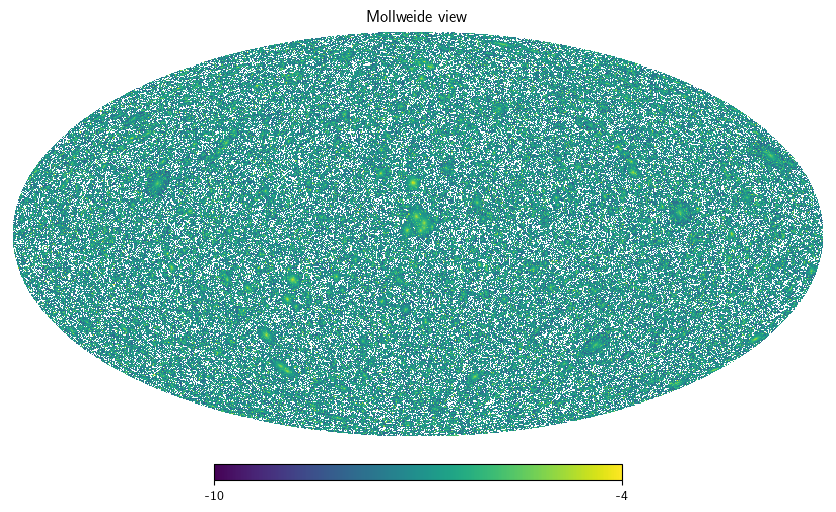

In [8]:
hp.mollview(np.log10(np.abs(tszmap_test)), min=-10, max=-4)



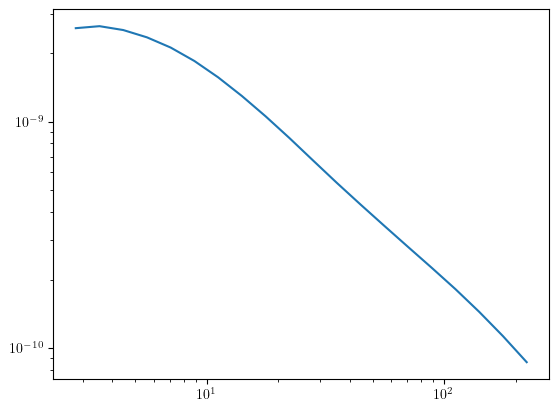

In [13]:
pl.figure()
pl.plot(xis_test.angles_data_array, xis_test.gty_out_mat[:,3])
pl.xscale('log')
pl.yscale('log')


In [5]:
df_cs = fits.open('/mnt/home/spandey/ceph/GODMAX/data/forecast/lsst_simulate_Y1.fits') 
bin1_vals =  df_cs['xip'].data['BIN1'][::20]
bin2_vals =  df_cs['xip'].data['BIN2'][::20]
biny_vals = np.array([1,2,3,4,5])

# index_gty = {}
index_gty = []
for js in range(100):
    # index_gty[js] = [js%20 ,js//20]
    index_gty.append([js%20 ,js//20])
index_gty = jnp.array(index_gty)
# index_xip = {}
index_xip = []
for js in range(300):
    binv = js//20
    thetav = js%20
    # index_xip[js] = [thetav ,bin1_vals[binv]-1, bin2_vals[binv]-1]
    index_xip.append([thetav ,bin1_vals[binv]-1, bin2_vals[binv]-1])
index_xip = jnp.array(index_xip)
# index_xim = {}
index_xim = []
for js in range(300):
    binv = js//20
    thetav = js%20
    # index_xim[js] = [thetav ,bin1_vals[binv]-1, bin2_vals[binv]-1]   
    index_xim.append([thetav ,bin1_vals[binv]-1, bin2_vals[binv]-1])
index_xim = jnp.array(index_xim)



In [6]:
# index_gty

In [7]:
xis_test = get_xi(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)


In [8]:
import jax 
from tqdm import tqdm
import copy
@jax.jit
def get_mean_cosmo(p):
    sim_params_dict_vary = copy.deepcopy(sim_params_dict)

    for jp in range(len(cosmo_params_vary_names)):
        sim_params_dict_vary['cosmo'][cosmo_params_vary_names[jp]] = p[jp]

    xis_test = get_xi(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict)

    def get_gty_from_index(index):
        index_val = index_gty[index]
        return xis_test.gty_out_mat[index_val[0], index_val[1]]

    def get_xip_from_index(index):
        index_val = index_xip[index]
        return xis_test.xip_out_mat[index_val[0], index_val[1], index_val[2]]

    def get_xim_from_index(index):
        index_val = index_xim[index]
        return xis_test.xim_out_mat[index_val[0], index_val[1], index_val[2]]

    gty_val = vmap(get_gty_from_index)(np.arange(100))
    xip_val = vmap(get_xip_from_index)(np.arange(300))
    xim_val = vmap(get_xim_from_index)(np.arange(300))

    mu = jnp.concatenate([gty_val, xip_val, xim_val])

    return mu




In [10]:
# cosmo_params_vary_names_all = ['Om0', 'Ob0', 'H0', 'ns', 'sigma8']
cosmo_params_vary_names_all = ['Om0']
cosmo_params_fid_all = np.zeros(len(cosmo_params_vary_names_all))
for jp in range(len(cosmo_params_vary_names_all)):
    cosmo_params_fid_all[jp] = sim_params_dict['cosmo'][cosmo_params_vary_names_all[jp]]

# dmu_cosmo_all = np.zeros((len(mean_dv_val), len(cosmo_params_vary_names_all)))
for jp in tqdm(range(len(cosmo_params_vary_names_all))):
    cosmo_params_vary_names = [cosmo_params_vary_names_all[jp]]
    params_fid = jnp.array([sim_params_dict['cosmo'][cosmo_params_vary_names_all[jp]]])    
    jac_mean = jax.jit(jax.jacfwd(get_mean_cosmo))
    dmu_cosmo = jac_mean(params_fid)


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:31<00:00, 31.66s/it]


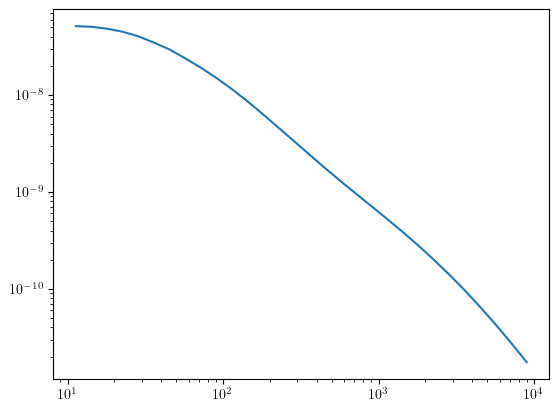

In [27]:
pl.figure()
pl.plot(Cls_test.ell_array, Cls_test.Cl_kappa_kappa_tot_mat[:,4,4])
pl.xscale('log')
pl.yscale('log')



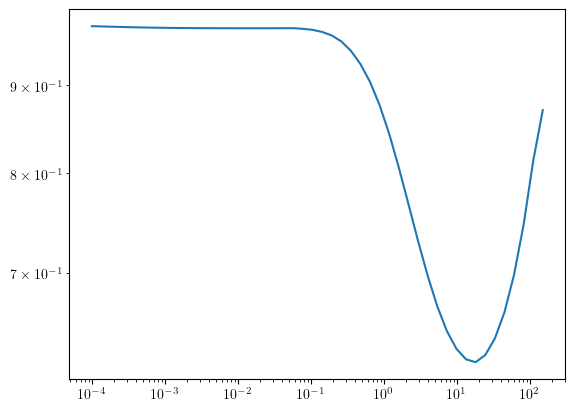

In [67]:
pl.figure()
# pl.plot(Pkz_test.kPk_array, np.array(Pkz_test.uk_dmb[:,0,10]), label='0h')
# pl.plot(Pkz_test.kPk_array, np.array(Pkz_test.Pmm_dmb_2h_kz_mat[:,0]), label='0h')
# pl.plot(Pkz_test.kPk_array, np.array(Pkz_test.Pmm_dmb_tot_mat[:,0]/Pkz_test.Pmm_nfw_tot_mat[:,0]), label='0h')
pl.plot(Pkz_test.kPk_array, np.array(Pkz_test.Pmm_dmb_tot_mat[:,5]/Pkz_test.Pmm_nfw_tot_mat[:,5]), label='0h')
pl.xscale('log')
pl.yscale('log')
# pl.ylim(0.8, 1.1)
# pl.xlim(1e-4, 5)

